# Maize nitrogen deficiency: annotated imagery classification dataset

Vlatko Galić, Filip Novoselnik, Miroslav Salaić and Ivana Podnar Žarko

In [1]:
from PIL import Image
import os
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
def resize_images(directory, size=(300, 300), ratio=False, metadata=False):
    """
    This function resizes images in a specified directory and saves them in a new subdirectory.

    Arguments:
        directory (str): Path to the directory containing the images.
        size (tuple): New size of the images. Default is (300, 300).
        ratio (bool): If set to True, the aspect ratio of the image is maintained. Default is False.
        metadata (bool): If set to True, the metadata of the image is retained and affects the size of the files. Default is False.

    Creates:
        A new subdirectory within the specified directory containing the resized images.
    """
    
    new_directory = os.path.join(directory, 'resized')
    if not os.path.exists(new_directory):
        os.makedirs(new_directory)
    for filename in os.listdir(directory):
        if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.JPG') or filename.endswith('.PNG'):
            image = Image.open(os.path.join(directory, filename))
            if not metadata:
                data = list(image.getdata())
                image = Image.new(image.mode, image.size)
                image.putdata(data)
            if ratio:
                width, height = image.size
                new_height = int(height * size[0] / width)
                image = image.resize((size[0], new_height))
            else:
                image = image.resize(size)
            image.save(os.path.join(new_directory, filename))

In [4]:
resize_images(directory=os.getcwd(),size=(100,100), ratio=False)

In [9]:
def load_images(directory, batch_size=100):
    
    """
    This function loads images from a specified directory in batches, applies data augmentation, and yields the images and their labels.

    Arguments:
        directory (str): Path to the directory containing the images.
        batch_size (int): Number of images to load in each batch. Default is 100.

    Returns:
        tuple: A tuple containing a batch of images and their corresponding labels.
    """
    
    images = []
    labels = []
    for i, filename in enumerate(os.listdir(directory)):
        if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.JPG') or filename.endswith('.PNG'):
            image = tf.io.read_file(os.path.join(directory, filename))
            image = tf.image.decode_jpeg(image, channels=3)
            #################################### ATTENTION ####################################
            #Adjust the size of the image to the input size of the model
            ###################################################################################

            image = tf.image.resize(image, (100, 100))
            image = tf.image.convert_image_dtype(image, tf.float32)
            images.append(image)
            
            # strip the label from the file name here
            label = filename.split(' ')[0]
            labels.append(label)
        
        if (i + 1) % batch_size == 0 or (i + 1) == len(os.listdir(directory)):
            images = tf.stack(images)
            labels = tf.stack(labels)
            
            # Augmentation of images
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal'),
                tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
            ])
            
            augmented_images = data_augmentation(images)
            images = tf.concat([images, augmented_images], axis=0)
            labels = tf.concat([labels, labels], axis=0)
            
            yield images, labels
            images = []
            labels = []



In [10]:
def encode_labels(labels):
    """
    This function encodes image labels into integers.

    Arguments:
        labels (Tensor): Tensor containing the labels.

    Returns:
        ndarray: NumPy array containing the encoded labels.
    """
    unique_labels, _ = tf.unique(labels)
    label_to_index = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(unique_labels, tf.range(tf.size(unique_labels))),
        -1
    )
    encoded_labels = label_to_index.lookup(labels)
    return encoded_labels.numpy() # convert to NumPy array

all_images = []
all_labels = []
for images, labels in load_images(os.path.join(os.getcwd(), 'resized'), batch_size=16): # add "resized" to the path if you want to use resized images
    if images.shape[0] > 0: # check if there are any images in the batch
        all_images.append(images)
        all_labels.append(labels)

all_images = tf.concat(all_images, axis=0)
all_labels = tf.concat(all_labels, axis=0)

# code labels
all_labels = encode_labels(all_labels)

# reshape images to 2d
all_images = tf.reshape(all_images, (all_images.shape[0], -1))

# balance the dataset for orthogonalization
ros = RandomOverSampler()
balanced_images, balanced_labels = ros.fit_resample(all_images.numpy(), all_labels)

# labels are floats, convert them to integers
balanced_labels = balanced_labels.astype(int)

# turn to tensors for easier manipulation and speed
balanced_images = tf.convert_to_tensor(balanced_images)
balanced_labels = tf.convert_to_tensor(balanced_labels)

# back to 3d
#################################### ATTENTION ####################################
#Adjust the size of the image to the input size of the model
###################################################################################
balanced_images = tf.reshape(balanced_images, (-1, 100, 100, 3))

# split into train and test sets
indices = tf.range(start=0, limit=balanced_images.shape[0], dtype=tf.int32)
train_indices, test_indices = tf.split(indices, num_or_size_splits=[int(0.8*balanced_images.shape[0]), int(0.2*balanced_images.shape[0])])
train_images = tf.gather(balanced_images, train_indices)
test_images = tf.gather(balanced_images, test_indices)
train_labels = tf.gather(balanced_labels, train_indices)
test_labels = tf.gather(balanced_labels, test_indices)

# back to tensors
train_images = tf.convert_to_tensor(train_images)
test_images = tf.convert_to_tensor(test_images)
train_labels = tf.convert_to_tensor(train_labels)
test_labels = tf.convert_to_tensor(test_labels)

dir=os.path.join(os.getcwd(), 'Images')
s = (100,100)

In [ ]:
# Alternative with segmentation
def load_images(directory, batch_size=100):
    images = []
    labels = []
    for i, filename in enumerate(os.listdir(directory)):
        if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.JPG') or filename.endswith('.PNG'):
            image = tf.io.read_file(os.path.join(directory, filename))
            image = tf.image.decode_jpeg(image, channels=3)
            image = tf.image.resize(image, s) # tu se isto mora prilagoditi input
            image = tf.image.convert_image_dtype(image, tf.float32)
            
            # Perform image segmentation
            segmented_image = segment_image(image)
            
            # Append the original and segmented images to the list
            images.append(image)
            images.append(segmented_image)
            
            label = filename.split(' ')[0]
            labels.append(label)
            labels.append(label) # Append the label twice since we have two images
        
        if (i + 1) % batch_size == 0 or (i + 1) == len(os.listdir(directory)):
            images = tf.stack(images)
            labels = tf.stack(labels)
            
            # Augmentacija udvostručuje broj slika nasumičnim rotacijama i horizontalnim preokretom
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal'),
                tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
            ])
            
            augmented_images = data_augmentation(images)
            images = tf.concat([images, augmented_images], axis=0)
            labels = tf.concat([labels, labels], axis=0)
            
            yield images, labels
            images = []
            labels = []
            

def segment_image(image, n_clusters=3):
    # Reshape the image into a 2D array of pixels
    pixels = tf.reshape(image, (-1, 3))
    pixels = pixels.numpy()
    
    # Fit the KMeans model to the pixel data
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(pixels)
    
    # Replace each pixel value with its nearest cluster center
    segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
    segmented_pixels = segmented_pixels.reshape(image.shape)
    
    # Convert the segmented image back to a TensorFlow tensor
    segmented_image = tf.convert_to_tensor(segmented_pixels)
    
    return segmented_image

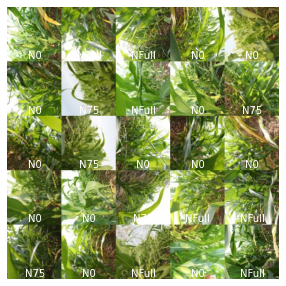

In [22]:
directory = os.path.join(os.getcwd(), 'resized')
batch_size = 100

# takes some time to load all images, smaller batch = faster
all_images = []
all_labels = []
for images, labels in load_images(directory, batch_size):
    all_images.append(images)
    all_labels.append(labels)

images = tf.concat(all_images, axis=0)
labels = tf.concat(all_labels, axis=0)

# normalize images
images = images / 255.0

indices = tf.range(images.shape[0])
indices = tf.random.shuffle(indices)
images = tf.gather(images, indices)
labels = tf.gather(labels, indices)

mosaic = np.hstack(np.hstack(images[:25].numpy().reshape(5, 5, 100, 100, 3)))

plt.figure(figsize=(5, 5))
plt.imshow(mosaic)
plt.axis('off')

for i in range(25):
    label = labels[i].numpy().decode('utf-8')
    x = (i % 5) * 100 + 50
    y = (i // 5) * 100 + 90
    plt.text(x, y, label, color='white', ha='center', va='center')

plt.show()
